# CNN Computer Vision Model

This notebook contains the implementation of a Convolutional Neural Network for computer vision tasks.

In [ ]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Task 1: Problem Identification
### Identify the type of computer vision problem the dataset represents

In [2]:
print("Problem Type: Multi-class Image Classification")
print("""
This dataset is suitable for Image Classification because:
- Each image belongs to exactly one class (normal, scratch, dent, stain).
- No bounding boxes or pixel-level masks are provided.
- Goal is to classify the entire image into one defect category.
""")

Problem Type: Multi-class Image Classification

This dataset is suitable for Image Classification because:
- Each image belongs to exactly one class (normal, scratch, dent, stain).
- No bounding boxes or pixel-level masks are provided.
- Goal is to classify the entire image into one defect category.



# Task 2: Dataset Exploration
### Analyze the image dataset


Number of Classes: 4
Total Images: 480

Number of Images per Class:
class
normal     120
scratch    120
dent       120
stain      120
Name: count, dtype: int64

Displaying Sample Images from Each Class...


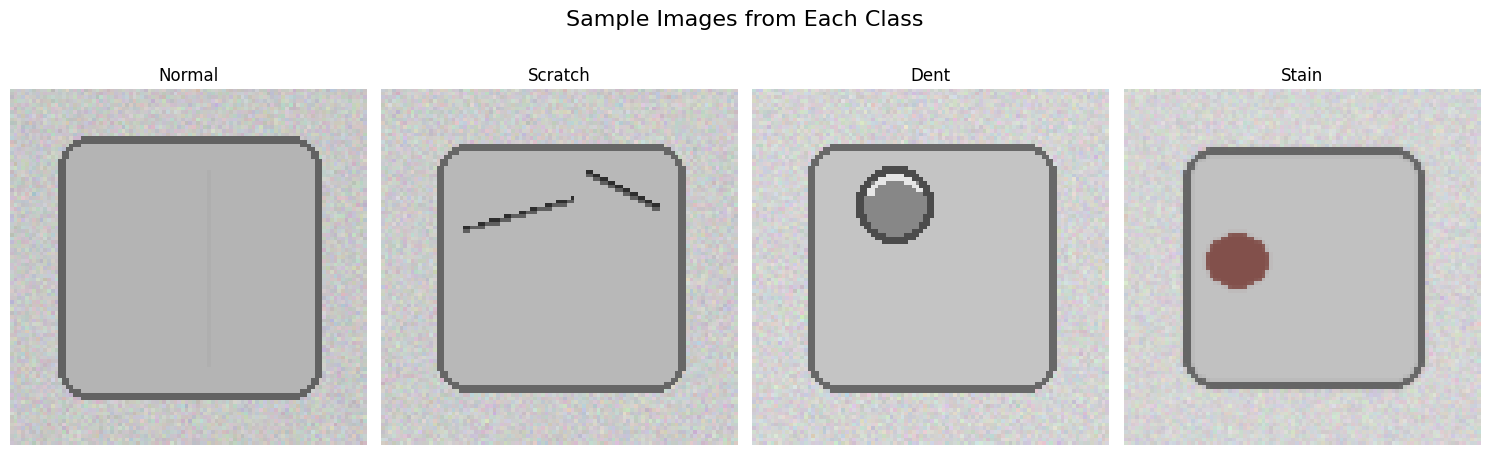

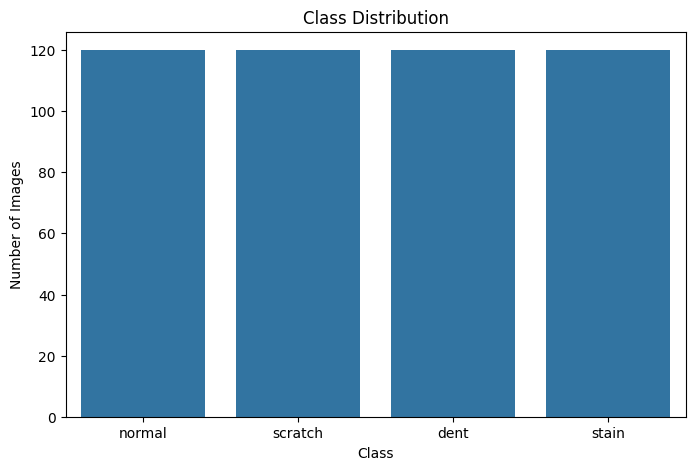


Image Dimensions (Height, Width, Channels): (96, 96, 3)

Class Distribution (%):
class
normal     25.0
scratch    25.0
dent       25.0
stain      25.0
Name: count, dtype: float64

✅ Dataset is perfectly balanced.


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2
import warnings
warnings.filterwarnings('ignore')

labels = pd.read_csv('labels.csv')

#Number of classses
print("\nNumber of Classes:", len(labels['class'].unique()))
print("Total Images:", len(labels))

#Number of images per class
print("\nNumber of Images per Class:")
class_counts = labels['class'].value_counts()
print(class_counts)

print("\nDisplaying Sample Images from Each Class...")

classes = labels['class'].unique()
fig, axes = plt.subplots(1, len(classes), figsize=(15, 5))

for i, cls in enumerate(classes):
    # Get one image from this class
    sample_file = labels[labels['class'] == cls]['filename'].iloc[0]
    img = cv2.imread(sample_file)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
    
    axes[i].imshow(img)
    axes[i].set_title(cls.capitalize())
    axes[i].axis('off')

plt.suptitle('Sample Images from Each Class', fontsize=16)
plt.tight_layout()
plt.show()

# Class distribution plot
plt.figure(figsize=(8, 5))
sns.countplot(data=labels, x='class', order=classes)
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Images')

plt.show()

# Image dimensions check
sample_img = cv2.imread(labels['filename'].iloc[0])
print("\nImage Dimensions (Height, Width, Channels):", sample_img.shape)

# Check for imbalance
total = len(labels)
print("\nClass Distribution (%):")
print(round(class_counts / total * 100, 2))

# Imbalance Analysis
if class_counts.std() > 5:  # Rough check
    print("\n⚠️  Dataset has moderate imbalance.")
else:
    print("\n✅ Dataset is perfectly balanced.")

# Task 3: Image Preprocessing
### Prepare the image data for model training.

In [24]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

# Encode labels
le = LabelEncoder()
labels['class_encoded'] = le.fit_transform(labels['class'])
num_classes = len(le.classes_)
print("Classes:", le.classes_)

# Load and preprocess images
def load_and_preprocess_image(img_path, target_size=(128, 128)):
    """Load image, resize it, and normalize pixel values"""
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)      # Convert from BGR to RGB
    img = cv2.resize(img, target_size)              # Resize to fixed size
    img = img.astype('float32') / 255.0             # Important: Normalize to [0, 1]
    return img

# Load images and their labels into arrays
X = []
y = []

for idx, row in labels.iterrows():
    img = load_and_preprocess_image(row['filename'])
    X.append(img)
    y.append(row['class_encoded'])

X = np.array(X)
y = np.array(y)

print(f"\nSuccessfully loaded {X.shape[0]} images with shape {X.shape[1:]}")

# One-hot encoding
y_cat = to_categorical(y, num_classes=num_classes)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, random_state=42, stratify=y, shuffle=True)

print("\nTraining shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Classes: ['dent' 'normal' 'scratch' 'stain']

Successfully loaded 480 images with shape (128, 128, 3)

Training shape: (384, 128, 128, 3)
Testing shape: (96, 128, 128, 3)


In [25]:
# We create some artificial variations of training images to help the model generalize better
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# For test data, we only normalize (no augmentation)
test_datagen = ImageDataGenerator()

print("Pixel values have been normalized between 0 and 1")
print("Data augmentation is ready for training to reduce overfitting")

Pixel values have been normalized between 0 and 1
Data augmentation is ready for training to reduce overfitting


# Task 4: CNN Model Creation
### Build a CNN model using TensorFlow/Keras or any suitable library.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import numpy as np

def create_cnn_model():
    """Create a simple but effective Convolutional Neural Network"""
    model = Sequential([
        
        # First convolutional layer - learns basic features like edges and colors
        Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
        MaxPooling2D(2,2),
        
        # Second convolutional layer - learns more complex patterns
        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2,2),
        
        # Third convolutional layer - captures even higher-level features
        Conv2D(128, (3,3), activation='relu'),
        MaxPooling2D(2,2),
        
        # Flatten the feature maps before feeding into dense layers
        Flatten(),
        
        # Fully connected layers for final classification
        Dense(128, activation='relu'),
        Dropout(0.5),                    # Helps prevent overfitting
        
        # Output layer - one neuron per class with softmax
        Dense(num_classes, activation='softmax')
    ])
    
    # Compile the model
    model.compile(
        optimizer='adam',                    # Popular and effective optimizer
        loss='categorical_crossentropy',     # Best for multi-class classification
        metrics=['accuracy']
    )
    
    return model

=== Task 4: Building the CNN Model ===


# Task 5: Model Training and Evaluation
### Train and evaluate your CNN model.

In [34]:
# Create and display model summary
model = create_cnn_model()
print("Model Architecture Summary:")
model.summary()

# Train the model
history = model.fit(
    X_train, 
    y_train,
    validation_split=0.2,      # Use 20% of training data for validation
    epochs=20,                 # You can increase this if needed
    batch_size=32,
    verbose=1
)

# MODEL EVALUATION
print("\nEvaluating model on test set...")

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Test Loss: {test_loss:.4f}")

# Training vs Validation Performance
print(f"\nBest Training Accuracy   : {max(history.history['accuracy']):.4f}")
print(f"Best Validation Accuracy : {max(history.history['val_accuracy']):.4f}")
print(f"\nBest Training Loss       : {min(history.history['loss']):.4f}")
print(f"Best Validation Loss     : {min(history.history['val_loss']):.4f}")

# PREDICTIONS 
# Get predictions for test images
y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

print("Predictions generated successfully!")

Model Architecture Summary:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 211ms/step - accuracy: 0.2671 - loss: 1.4235 - val_accuracy: 0.2338 - val_loss: 1.3898
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 185ms/step - accuracy: 0.2671 - loss: 1.3903 - val_accuracy: 0.2338 - val_loss: 1.3841
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 188ms/step - accuracy: 0.3485 - loss: 1.3647 - val_accuracy: 0.4156 - val_loss: 1.3101
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 206ms/step - accuracy: 0.4756 - loss: 1.1897 - val_accuracy: 0.6494 - val_loss: 1.0492
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 189ms/step - accuracy: 0.5961 - loss: 0.9298 - val_accuracy: 0.7273 - val_loss: 0.8101
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 189ms/step - accuracy: 0.7134 - loss: 0.6913 - val_accuracy: 0.7143 - val_loss: 0.6236
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 183ms/step - accuracy: 0.7622 - loss: 0.5630 - val_accuracy: 0.9091 - val_loss: 0.6262
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 211ms/step - accuracy: 0.8046 - loss: 0.5337 - val_accuracy: 0.

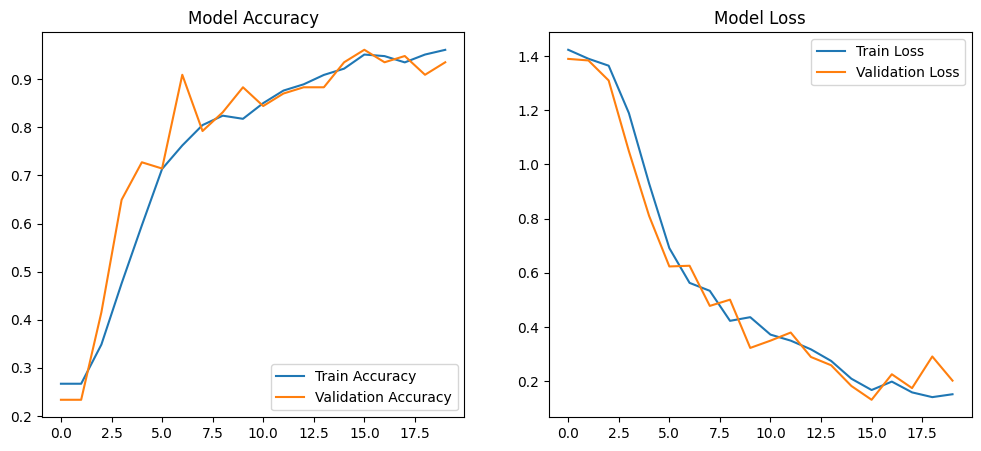

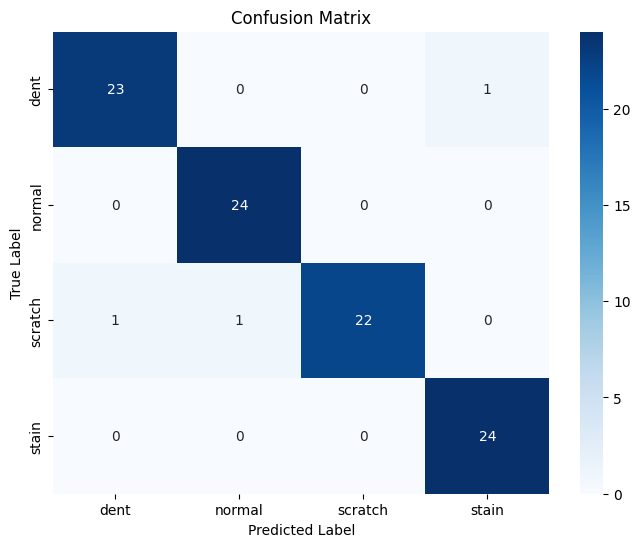

In [35]:
# Accuracy & Loss Curves
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.legend()

plt.savefig('results/accuracy_loss_curves.png')
plt.show()

# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('results/confusion_matrix.png')
plt.show()


=== Displaying Sample Predictions on Test Images ===


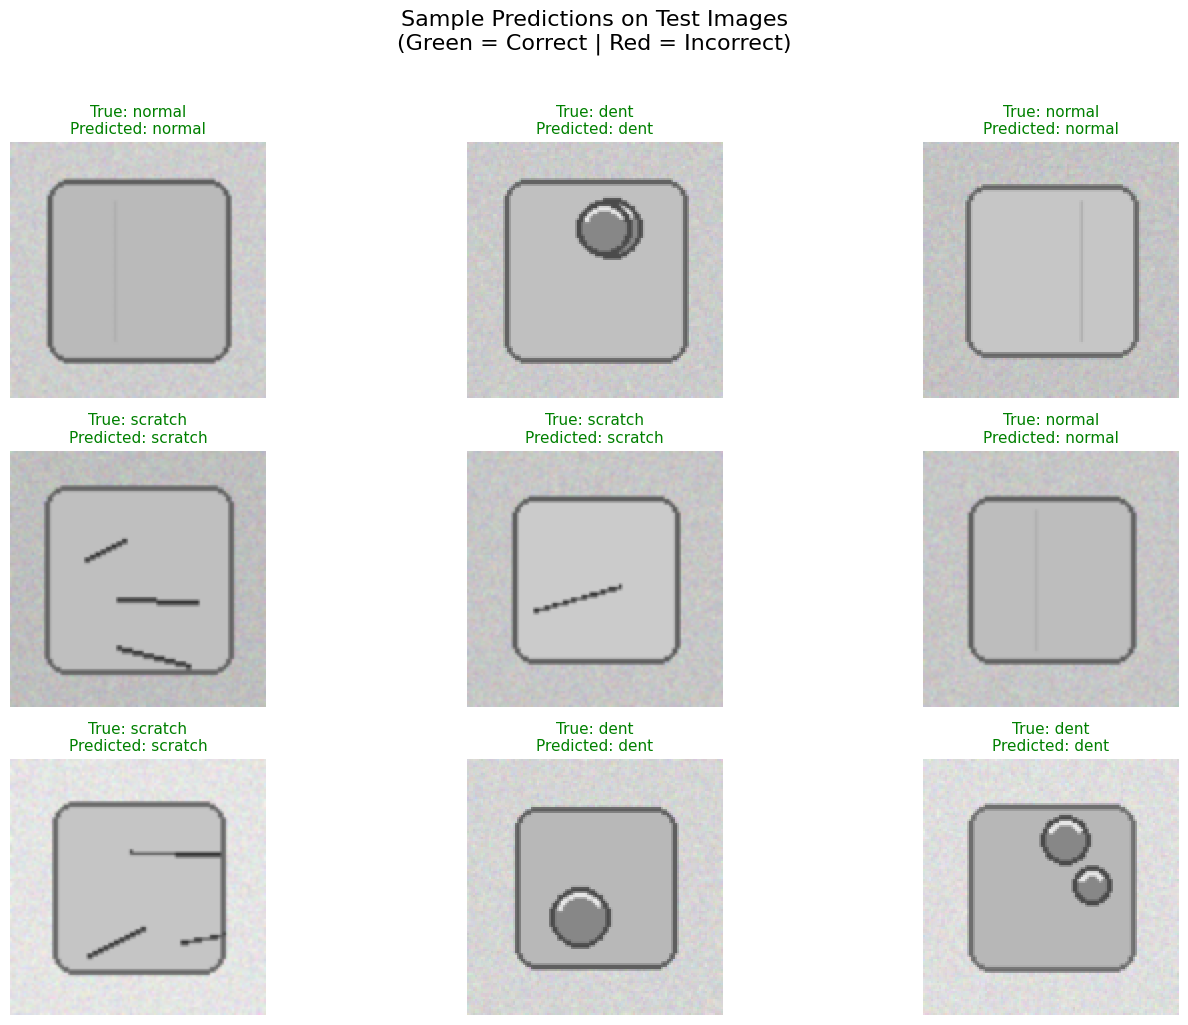

Sample predictions saved to 'sample_predictions/prediction_outputs.png'


In [36]:
# ====================== SAMPLE PREDICTIONS ON TEST IMAGES ======================
print("\n=== Displaying Sample Predictions on Test Images ===")


# Set up the plot
plt.figure(figsize=(15, 10))
num_samples = 9  # Display 9 random test images

# Randomly select 9 test images
indices = np.random.choice(len(X_test), num_samples, replace=False)

for i, idx in enumerate(indices):
    plt.subplot(3, 3, i + 1)
    
    # Display the image
    plt.imshow(X_test[idx])
    
    # Get true and predicted labels
    true_label = le.classes_[y_true_classes[idx]]
    pred_label = le.classes_[y_pred_classes[idx]]
    
    # Color code: Green if correct, Red if wrong
    color = 'green' if true_label == pred_label else 'red'
    
    plt.title(f"True: {true_label}\nPredicted: {pred_label}", 
              color=color, fontsize=11)
    plt.axis('off')

plt.suptitle('Sample Predictions on Test Images\n(Green = Correct | Red = Incorrect)', 
             fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('sample_predictions/prediction_outputs.png', dpi=300, bbox_inches='tight')
plt.show()

print("Sample predictions saved to 'sample_predictions/prediction_outputs.png'")